# ❤️ Heart Disease Classification using Machine Learning

## 📌 Objective
The goal of this project is to build a machine learning model that predicts whether a patient has heart disease based on medical attributes.

## 🧠 Problem Type
Binary Classification

## 📊 Dataset
The dataset contains medical features such as:
- Age
- Sex
- Chest Pain Type
- Blood Pressure
- Cholesterol
- Maximum Heart Rate
- etc.

Target:
- 0 → No Heart Disease
- 1 → Heart Disease

In [1]:
# Library for data manipulation and analysis (tables, CSV, etc.)
import pandas as pd

# Library for numerical operations (arrays, math, NaN handling, etc.)
import numpy as np

# Library for creating static plots
import matplotlib.pyplot as plt

# Library for advanced statistical plots
import seaborn as sns

# Functions for splitting data, preprocessing, and evaluation
from sklearn.model_selection import train_test_split   # For splitting dataset into train/test
from sklearn.preprocessing import OneHotEncoder        # For encoding categorical variables
from sklearn.compose import ColumnTransformer          # For applying preprocessing to different column types
from sklearn.pipeline import Pipeline                  # To combine preprocessing + model in one object
from sklearn.impute import SimpleImputer               # To handle missing values
from sklearn.metrics import (accuracy_score,           # Overall accuracy
                             confusion_matrix,         # Confusion matrix (TP, FP, TN, FN)
                             classification_report,    # Precision, Recall, F1 per class
                             roc_auc_score,            # ROC-AUC score
                             roc_curve,                # ROC curve points
                             precision_score,          # Precision (positive predictive value)
                             recall_score,             # Recall (sensitivity / true positive rate)
                             f1_score                  # F1-score (balance of precision & recall)
)

# Machine learning models
from sklearn.tree import DecisionTreeClassifier, plot_tree   # Decision Tree model and visualization
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier # Random Forest, Gradient Boosting classificayion models and Voting for ensemble multiple modeles

In [2]:
# ========================
# 2. Load Dataset
# ========================

df = pd.read_csv("heart_disease.xls")

# Preview data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,0,145.0,233.0,1,2,150,0,2.3,2,0,2,0
1,67,Male,3,160.0,286.0,0,2,108,1,1.5,1,3,1,1
2,67,Male,3,120.0,229.0,0,2,129,1,2.6,1,2,3,1
3,37,Male,2,130.0,250.0,0,0,187,0,3.5,2,0,1,0
4,41,Female,1,130.0,204.0,0,2,172,0,1.4,0,0,1,0


In [3]:
# ========================
# 3. Data Understanding
# ========================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    int64  
 3   trestbps  298 non-null    float64
 4   chol      298 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 33.3+ KB


,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,298.000000,298.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,2.158416,131.657718,246.671141,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.960126,17.479867,52.042257,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,2.000000,130.000000,240.500000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


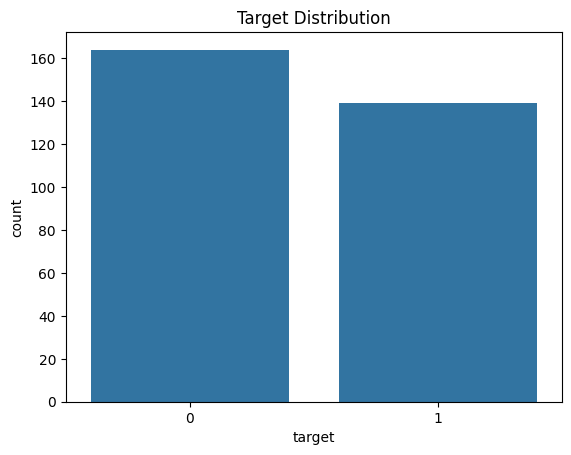

In [4]:
# Target distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

In [5]:
# ========================
# 4. Data Preprocessing
# ========================

# Drop unnecessary columns if exist
df = df.drop(columns=['num'], errors='ignore')

# Split features & target
X = df.drop('target', axis=1)
y = df['target']



In [ ]:
# Check missing values
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    5
chol        5
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [7]:
# Replace "?" with NaN (so they can be detected as missing)
X = X.replace('?', np.nan)

In [8]:
# check duplicates 
print(X.duplicated().sum())

0


In [9]:
# Convert values to numeric type 
# errors='ignore' → skip if cannot convert
X = X.apply(pd.to_numeric, errors='ignore')

C:\Users\dell\AppData\Local\Temp\ipykernel_1372\2994562519.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = X.apply(pd.to_numeric, errors='ignore')


In [10]:
# Select categorical columns
# [col for col in X.columns if ...] → list comprehension
# X[col].dtype == 'object' → text/categorical type
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

In [11]:
# Print categorical columns list
print("Categorical columns:", categorical_cols)

Categorical columns: ['sex']


In [12]:
# Select numeric columns
# dtype 'int64' or 'float64' → numbers
numeric_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]

In [13]:
# Print numerical columns list
print("Numeric columns:", numeric_cols)

Numeric columns: ['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [14]:
# ============================================================
# 5. Build and configure Preprocessing Pipelines
# ============================================================

# Create pipeline for numeric columns
numeric_transformer = Pipeline(steps=[  
    # 'steps' takes a list [] of (name, operation)
    # ('imputer', SimpleImputer(strategy='median')) → 
    #   name = 'imputer'
    #   SimpleImputer = fills missing values
    #   strategy='median' → replace with column median
    ('imputer', SimpleImputer(strategy='median'))
])



In [15]:
# Create pipeline for categorical columns
categorical_transformer = Pipeline(steps=[
    # First step → replace missing values with most frequent category
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Second step → OneHotEncoder
    # Converts categorical labels into multiple 0/1 columns
    # handle_unknown='ignore' → skip unseen categories at test time
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
# Combine both numeric and categorical pipelines
preprocessor = ColumnTransformer(
    transformers=[  
        # Each item: (name, transformer, columns)
        # 'num' → name, numeric_transformer → pipeline, numeric_cols → apply to these columns
        ('num', numeric_transformer, numeric_cols),  
        # 'cat' → name, categorical_transformer → pipeline, categorical_cols → apply to these columns
        ('cat', categorical_transformer, categorical_cols)  
    ])

In [21]:
# ========================
# 6. Train/Test Split
# ========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    int64  
 3   trestbps  298 non-null    float64
 4   chol      298 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 30.9+ KB


## 🧠 Modeling Strategy

Instead of relying on a single model, we apply multiple algorithms with different assumptions:

- Decision Tree:
  A simple and interpretable baseline model.

- Random Forest:
  An ensemble of trees using bagging to reduce overfitting and variance.

- Gradient Boosting:
  A sequential model that improves weak learners by focusing on previous errors.

To improve robustness, we combine models using **Soft Voting**, which averages predicted probabilities.

👉 This reduces variance and improves generalization.

In [23]:
# ==============================================================
# 7. Initialize (Decision Tree) Model
# ==============================================================


# Create a pipeline that does 2 things in order:
# 1. Apply preprocessing (handle missing values, encoding, etc.)
# 2. Train a Decision Tree classifier
dt_pipeline = Pipeline(steps=[
    # Step 1: preprocessing (the preprocessor we built earlier)
    ('preprocessor', preprocessor),                     
    # Step 2: Decision Tree Classifier
    # max_depth=4 → tree will only go 4 levels deep (prevents overfitting)
    # random_state=42 → makes results reproducible
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))  
])

In [25]:
# Train (fit) the pipeline on training data
# X_train → input features, y_train → target labels

dt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
# Use the trained model to make predictions on test data
# X_test → unseen input features
y_pred_dt = dt_pipeline.predict(X_test)   

In [27]:
# ==============================================================
# 8. Evaluate (Decision Tree) Model
# ==============================================================


# Print results for Decision Tree model
print("\n=== Decision Tree Results ===")  # \n adds a new empty line before printing
# Print accuracy (correct predictions ÷ total predictions)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))     
# Print detailed report: precision, recall, f1-score for each class
print(classification_report(y_test, y_pred_dt))     


=== Decision Tree Results ===
Accuracy: 0.7868852459016393
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        33
           1       0.74      0.82      0.78        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [28]:
# ==============================================================
# 9. Initialize (Random Forest) Model
# ==============================================================



# Create a pipeline that does 2 things in order:
# 1. Apply preprocessing (handle missing values, encoding, etc.)
# 2. Train a Decision Tree classifier
rf_pipeline = Pipeline(steps=[
    # Step 1: preprocessing (the preprocessor we built earlier)
    ('preprocessor', preprocessor),                     
    # Step 2: Random Forest Classifier
    # n_estimators=100 → builds 100 decision trees (more trees = better stability)
    # random_state=42 → ensures reproducible results
    # Each tree is trained on different bootstrap samples + random features → reduces overfitting
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42)) 
])

In [29]:
# Train (fit) the pipeline on training data
# X_train → input features, y_train → target labels
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
# Use the trained model to make predictions on test data
# X_test → unseen input features
y_pred_rf = rf_pipeline.predict(X_test)   

In [31]:
# ==============================================================
# 10. Evaluate (Random Forest) Model
# ==============================================================


# Print results for Decision Tree model
print("\n=== Random Forest Results ===")  # \n adds a new empty line before printing
# Print accuracy (correct predictions ÷ total predictions)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))     
# Print detailed report: precision, recall, f1-score for each class
print(classification_report(y_test, y_pred_rf))     


=== Random Forest Results ===
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [32]:
# ==============================================================
# 11. Initialize (Ensembled) Models
# ==============================================================


# Initialize Base models
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

In [33]:
# Model Voting

# Soft Voting Classifier
# Each model gives probabilities for each class.
# The probabilities are averaged.
# The final prediction is the class with the highest average probability.
# Example:
#   DT → Disease=0.6, No Disease=0.4
#   RF → Disease=0.8, No Disease=0.2
#   GB → Disease=0.7, No Disease=0.3
#   Average → Disease=0.7, No Disease=0.3 → Final = Disease
voting_clf_soft = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('soft_classifier', VotingClassifier(
        estimators=[('dt', dt), ('rf', rf), ('gb', gb)],
        voting='soft'   # probability-based voting
    ))
])

In [34]:
# ==============================================================
# 12 Train (Ensembled) Soft Voting Model
# ==============================================================


# Train (fit) the pipeline on training data
# X_train → input features, y_train → target labels
voting_clf_soft.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('soft_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# Use the trained model to make predictions on test data
# X_test → unseen input features
y_pred_softens = voting_clf_soft.predict(X_test) 

In [36]:
# ==============================================================
# 13. Evaluate (Ensembled) Model
# ==============================================================



# Print results for Decision Tree model
print("\n=== Ensembled (Soft Voting) Results ===")  # \n adds a new empty line before printing
# Print accuracy (correct predictions ÷ total predictions)
print("Accuracy:", accuracy_score(y_test, y_pred_softens))     
# Print detailed report: precision, recall, f1-score for each class
print(classification_report(y_test, y_pred_softens))     


=== Ensembled (Soft Voting) Results ===
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



## 📊 Model Performance Analysis

- Decision Tree achieved an accuracy of ~78.7%, serving as a simple baseline model.
- Random Forest significantly improved performance to ~86.9%, due to its ensemble nature and ability to reduce overfitting.
- The Soft Voting ensemble achieved the same accuracy (~86.9%) as Random Forest.

👉 This indicates that Random Forest is already a strong and stable model for this dataset.

## 🤝 Ensemble Performance Insight

Although ensemble learning is expected to improve performance, in this case:

- Random Forest already provides strong generalization.
- Decision Tree is a weaker model and may not contribute useful additional information.
- As a result, Soft Voting did not significantly outperform Random Forest.

👉 This suggests that adding weak or similar models to an ensemble does not always improve results.

In [40]:
#Final Accuracy Results 
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Soft Voting"],
    "Accuracy": [0.787, 0.869, 0.869]
})

comparison

,Model,Accuracy
0,Decision Tree,0.787
1,Random Forest,0.869
2,Soft Voting,0.869


## 📌 Final Conclusion

- Random Forest achieved the highest overall accuracy.
- Ensemble learning did not improve accuracy but improved recall for detecting heart disease cases.
- For medical applications, recall is more important than accuracy.

👉 Therefore:
- Random Forest is the best general model.
- Soft Voting is preferred when prioritizing disease detection.